### Setup

In [169]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import OrderedDict

In [170]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

device

'cuda'

### Load Dataset

In [171]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", ]

df = pd.read_csv(url, names=columns, na_values="?", sep=r"\s+", usecols=range(8), )

df = df.dropna()

df = df.dropna()

print(df.shape)

df.head()

(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


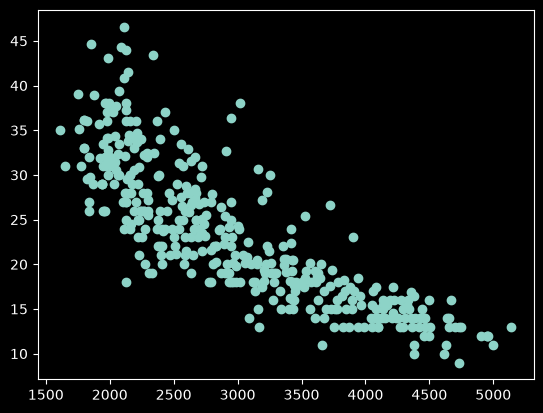

In [172]:
plt.scatter(df[["weight"]].values, df[["mpg"]].values)

In [173]:
X = torch.tensor(df[["weight"]].values, dtype=torch.float32, device=device)

y = torch.tensor(df[["mpg"]].values, dtype=torch.float32, device=device)

In [174]:
X_mean = X.mean()
X_std = X.std()
X = (X-X_mean)/X_std

y_mean = y.mean()
y_std = y.std()
y = (y-y_mean)/y_std

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([313, 1]),
 torch.Size([79, 1]),
 torch.Size([313, 1]),
 torch.Size([79, 1]))

### Model

In [176]:
class ModelNNN(nn.Module):
    def __init__(self, input_n, M, ns, output_n):
        super().__init__()
        layers = {}
        ns.insert(0, input_n)
        c = 0
        for layer in range(M):
            layers.update({str(c) : nn.Linear(ns[layer], ns[layer+1]), str(c+1): nn.ReLU()})
            c += 2
        self.block = nn.Sequential(OrderedDict(layers))
        self.output_layer = nn.Linear(ns[-1], output_n)

    def forward(self, X):
        block_output = self.block(X)
        return self.output_layer(block_output)

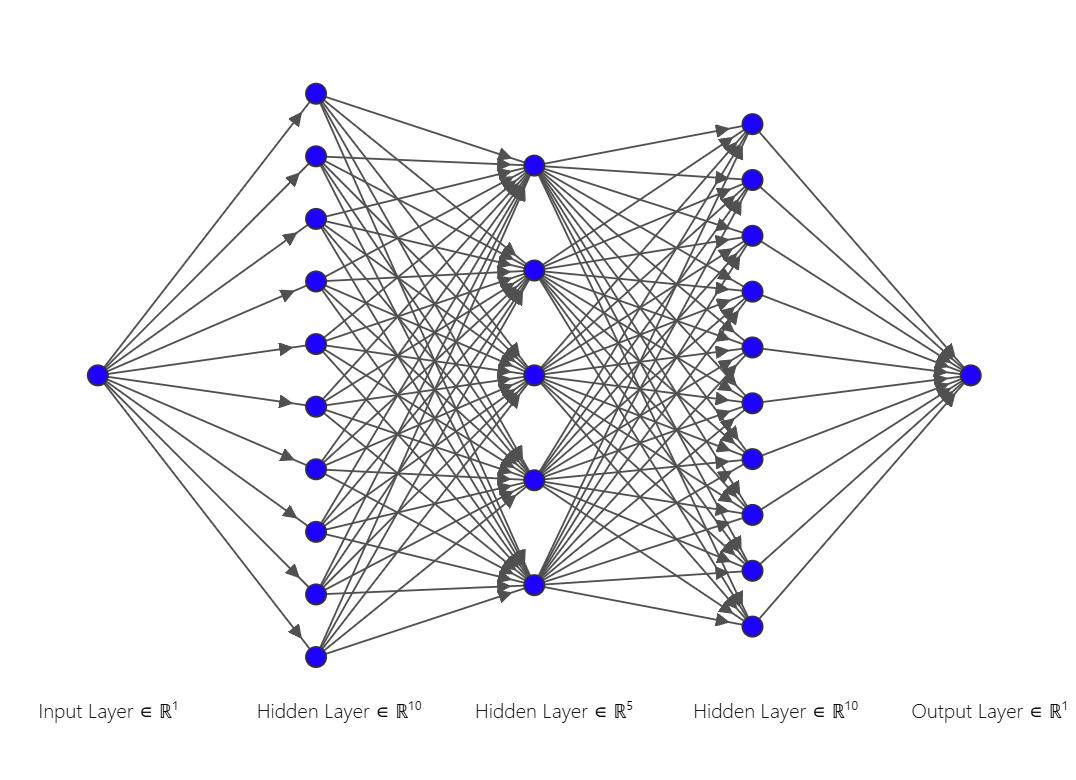
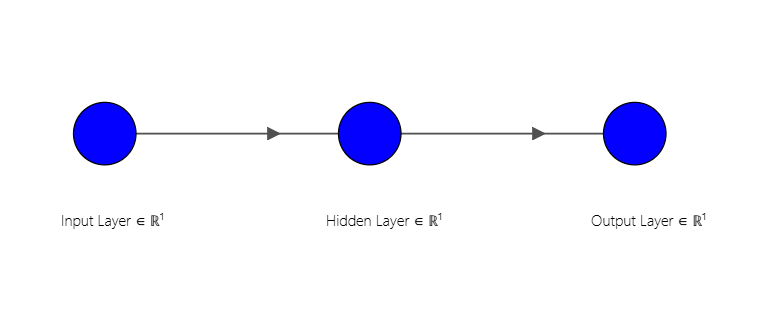
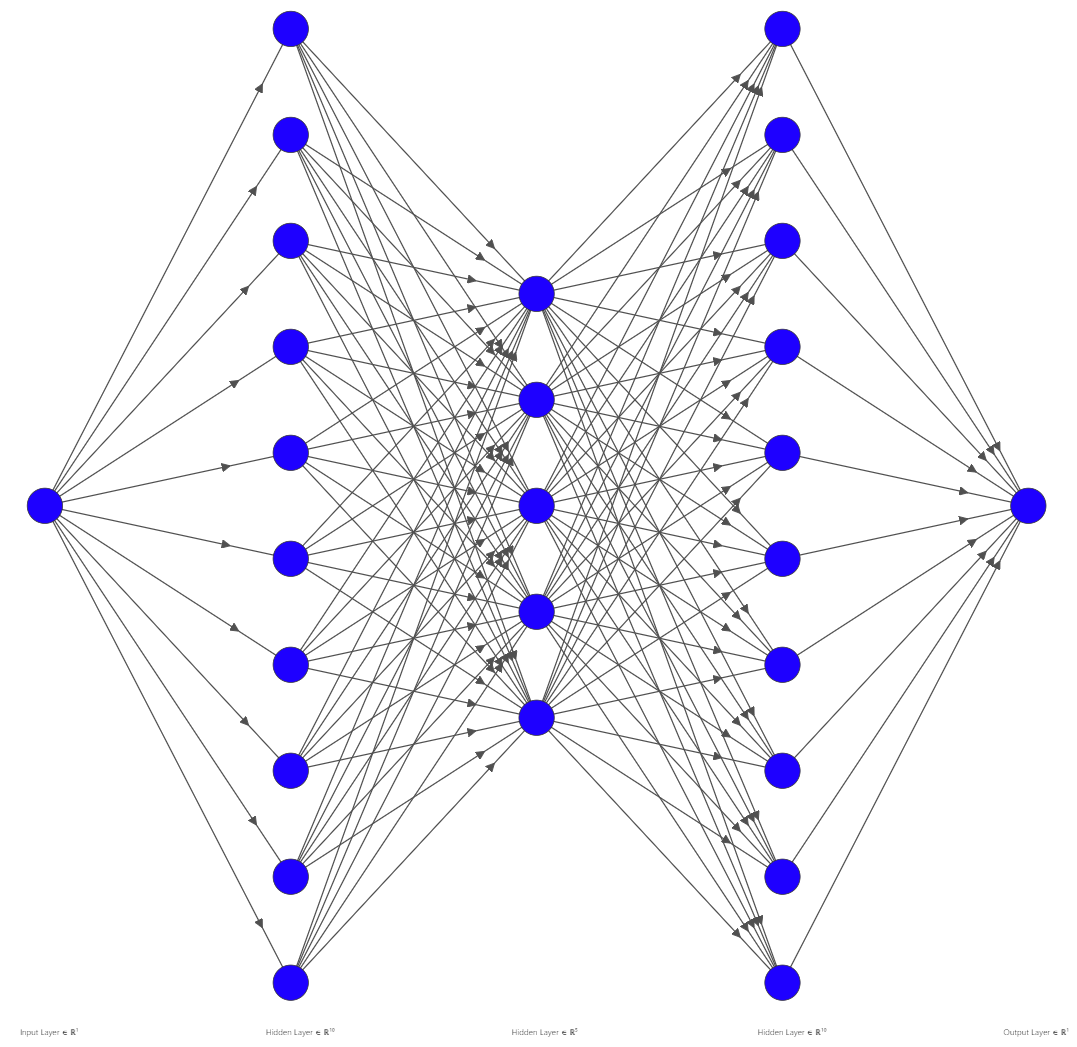

In [177]:
model = ModelNNN(1, 3, [10, 5, 10], 1)
model = model.to(device)
model

ModelNNN(
  (block): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=10, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=10, out_features=1, bias=True)
)

### Training

In [178]:
def train(model, optimizer, criterion, X, y, n_epochs):
    losses = []
    for epoch in range(n_epochs):
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")
    return losses

In [179]:
learning_rate = 0.1
n_epochs = 30

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [180]:
loss = train(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/30, Loss: 1.0369336605072021
Epoch 2/30, Loss: 1.0152158737182617
Epoch 3/30, Loss: 0.9979193210601807
Epoch 4/30, Loss: 0.9823335409164429
Epoch 5/30, Loss: 0.9669057726860046
Epoch 6/30, Loss: 0.9505221247673035
Epoch 7/30, Loss: 0.9322007298469543
Epoch 8/30, Loss: 0.9108715653419495
Epoch 9/30, Loss: 0.8856208920478821
Epoch 10/30, Loss: 0.8555706143379211
Epoch 11/30, Loss: 0.8212170004844666
Epoch 12/30, Loss: 0.7816274166107178
Epoch 13/30, Loss: 0.7400685548782349
Epoch 14/30, Loss: 0.6913301348686218
Epoch 15/30, Loss: 0.6420003175735474
Epoch 16/30, Loss: 0.5883094072341919
Epoch 17/30, Loss: 0.535588264465332
Epoch 18/30, Loss: 0.4856654107570648
Epoch 19/30, Loss: 0.441416472196579
Epoch 20/30, Loss: 0.4035837650299072
Epoch 21/30, Loss: 0.37421944737434387
Epoch 22/30, Loss: 0.35327285528182983
Epoch 23/30, Loss: 0.3394763171672821
Epoch 24/30, Loss: 0.3308005928993225
Epoch 25/30, Loss: 0.32544490694999695
Epoch 26/30, Loss: 0.3221585750579834
Epoch 27/30, Loss: 0

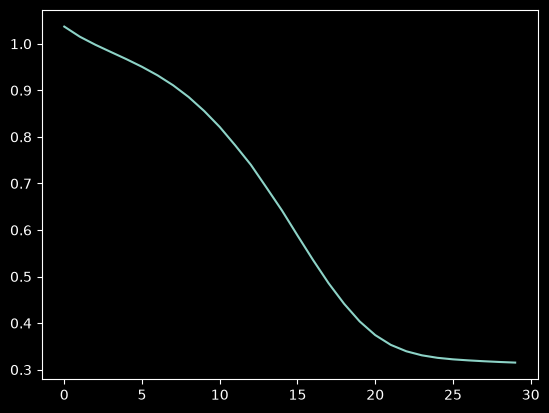

In [181]:
plt.plot(list(range(n_epochs)), loss)

### Evaluate

In [182]:
def evaluate(model, X, y, metric_fn, aggregate_fn=torch.mean):
    model.eval()
    metrics = []
    with torch.no_grad():
        for X_data, y_data in zip(X, y):
            y_pred = model(X_data)
            metric = metric_fn(y_pred, y_data)
            metrics.append(metric)
    return aggregate_fn(torch.stack(metrics))

In [183]:
evaluate(model, X_test, y_test, mse)

tensor(0.2672, device='cuda:0')

end